In [1]:
import pandas as pd
import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt


In [2]:

# Load cleaned dataset
train_df = pd.read_csv("../data/clean_train.csv")
val_df   = pd.read_csv("../data/clean_val.csv")



In [3]:
# Tokenization
VOCAB_SIZE = 10000
MAX_LEN = 100
EMBED_DIM = 100

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df['tweet_content'])


In [4]:

X_train = pad_sequences(tokenizer.texts_to_sequences(train_df['tweet_content']), maxlen=MAX_LEN)
X_val   = pad_sequences(tokenizer.texts_to_sequences(val_df['tweet_content']), maxlen=MAX_LEN)

y_train = to_categorical(train_df['label'], num_classes=3)
y_val   = to_categorical(val_df['label'], num_classes=3)


In [5]:

# Load GloVe embeddings
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM))
with open("../data/glove.6B.100d.txt", encoding="utf8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype='float32')
        index = tokenizer.word_index.get(word)
        if index and index < VOCAB_SIZE:
            embedding_matrix[index] = vector


In [6]:

# Simple RNN
rnn_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
    SimpleRNN(64),
    Dense(3, activation='softmax')
])
rnn_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
rnn_history = rnn_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=5, batch_size=64)


e:\anaconda\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/5
934/934 ━━━━━━━━━━━━━━━━━━━━ 36s 34ms/step - accuracy: 0.5495 - loss: 0.9494 - val_accuracy: 0.6022 - val_loss: 0.8585
Epoch 2/5
934/934 ━━━━━━━━━━━━━━━━━━━━ 24s 26ms/step - accuracy: 0.6039 - loss: 0.8770 - val_accuracy: 0.6094 - val_loss: 0.8414
Epoch 3/5
934/934 ━━━━━━━━━━━━━━━━━━━━ 26s 27ms/step - accuracy: 0.5844 - loss: 0.9054 - val_accuracy: 0.5683 - val_loss: 0.9221
Epoch 4/5
934/934 ━━━━━━━━━━━━━━━━━━━━ 22s 23ms/step - accuracy: 0.6155 - loss: 0.8558 - val_accuracy: 0.6518 - val_loss: 0.8098
Epoch 5/5
934/934 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - accuracy: 0.6414 - loss: 0.8114 - val_accuracy: 0.6542 - val_loss: 0.7707


In [7]:

# LSTM
lstm_model = Sequential([
    Embedding(VOCAB_SIZE, EMBED_DIM, weights=[embedding_matrix], input_length=MAX_LEN, trainable=False),
    LSTM(64),
    Dense(3, activation='softmax')
])
lstm_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
lstm_history = lstm_model.fit(X_train, y_train, validation_data=(X_val, y_val), epochs=5, batch_size=64)


Epoch 1/5
934/934 ━━━━━━━━━━━━━━━━━━━━ 83s 85ms/step - accuracy: 0.6247 - loss: 0.8421 - val_accuracy: 0.6747 - val_loss: 0.7376
Epoch 2/5
934/934 ━━━━━━━━━━━━━━━━━━━━ 75s 81ms/step - accuracy: 0.6948 - loss: 0.7141 - val_accuracy: 0.7400 - val_loss: 0.6080
Epoch 3/5
934/934 ━━━━━━━━━━━━━━━━━━━━ 65s 69ms/step - accuracy: 0.7405 - loss: 0.6197 - val_accuracy: 0.8053 - val_loss: 0.5072
Epoch 4/5
934/934 ━━━━━━━━━━━━━━━━━━━━ 68s 73ms/step - accuracy: 0.7847 - loss: 0.5316 - val_accuracy: 0.8295 - val_loss: 0.4347
Epoch 5/5
934/934 ━━━━━━━━━━━━━━━━━━━━ 66s 70ms/step - accuracy: 0.8155 - loss: 0.4622 - val_accuracy: 0.8597 - val_loss: 0.3795


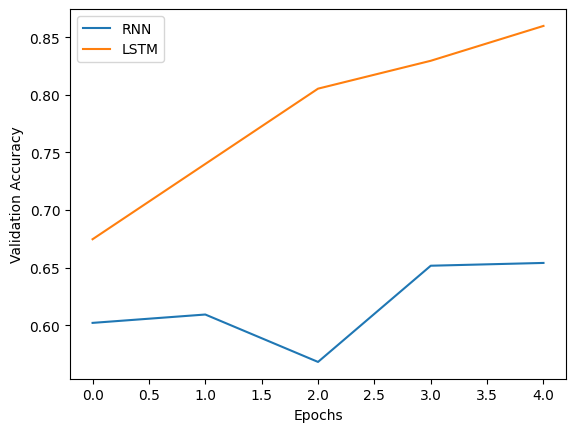

In [8]:

# Plot validation accuracy
plt.plot(rnn_history.history['val_accuracy'], label='RNN')
plt.plot(lstm_history.history['val_accuracy'], label='LSTM')
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()


In [9]:

# Save models
import joblib


rnn_model.save("../models/rnn_model.h5")
lstm_model.save("../models/lstm_model.h5")
joblib.dump(tokenizer, "../models/tokenizer.pkl")

['../models/tokenizer.pkl']